# eigenfaces: class dataset

same pipeline as the olivetti notebook, but applied to our own photos. 26 people, 3 images each.

to reduce bias from lighting, hair, and framing, we keep the preprocessing simple:
- center-crop each image
- convert to grayscale
- equalize contrast
- apply a face-centered mask

since we only have 3 images per person, we use **leave-one-out**: 2 images per person go to training, 1 to testing.

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image, ImageOps
from sklearn.decomposition import PCA

IMG_SIZE = (64, 64)
DATASET_PATH = "class_pictures"
CELEB_DATASET_PATH = "celebrity_pictures"

def gaussian2d(xx, yy, cx, cy, sx, sy):
    return np.exp(-(((xx - cx) ** 2) / (2 * sx ** 2) + ((yy - cy) ** 2) / (2 * sy ** 2)))

def feature_weight_map(shape):
    h, w = shape
    yy, xx = np.mgrid[:h, :w].astype(np.float32)

    face   = gaussian2d(xx, yy, w * 0.50, h * 0.52, w * 0.23, h * 0.30)
    lbrow  = gaussian2d(xx, yy, w * 0.35, h * 0.30, w * 0.07, h * 0.03)
    rbrow  = gaussian2d(xx, yy, w * 0.65, h * 0.30, w * 0.07, h * 0.03)
    leye   = gaussian2d(xx, yy, w * 0.35, h * 0.39, w * 0.06, h * 0.04)
    reye   = gaussian2d(xx, yy, w * 0.65, h * 0.39, w * 0.06, h * 0.04)
    nose   = gaussian2d(xx, yy, w * 0.50, h * 0.54, w * 0.05, h * 0.10)
    mouth  = gaussian2d(xx, yy, w * 0.50, h * 0.70, w * 0.10, h * 0.05)

    weights = (
        0.45 * face +
        1.00 * lbrow + 1.00 * rbrow +
        1.10 * leye  + 1.10 * reye +
        1.00 * nose +
        1.00 * mouth
    )

    weights = weights / weights.max()
    return 0.35 + 0.65 * weights

def preprocess_image(path):
    img = Image.open(path).convert("L")
    img = ImageOps.fit(
        img,
        IMG_SIZE,
        method=Image.Resampling.LANCZOS,
        centering=(0.5, 0.45)
    )

    display_arr = np.array(img, dtype=np.float32) / 255.0

    img_eq = ImageOps.equalize(img)
    arr = np.array(img_eq, dtype=np.float32) / 255.0

    gy, gx = np.gradient(arr)
    edges = np.sqrt(gx**2 + gy**2)
    edges = edges / (edges.max() + 1e-8)

    weights = feature_weight_map(arr.shape)

    # keep the image looking like a face, but bias the math toward facial structure
    features = (0.85 * arr + 0.15 * edges) * weights
    features = np.clip(features, 0, 1)

    return features.flatten(), display_arr.flatten()

def load_dataset(root):
    X, X_display, y, label_map = [], [], [], {}
    for idx, person in enumerate(sorted(os.listdir(root))):
        person_dir = os.path.join(root, person)
        if not os.path.isdir(person_dir):
            continue
        label_map[idx] = person
        for fname in sorted(os.listdir(person_dir)):
            if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            path = os.path.join(person_dir, fname)
            feat, disp = preprocess_image(path)
            X.append(feat)
            X_display.append(disp)
            y.append(idx)
    return np.array(X), np.array(X_display), np.array(y), label_map

def load_celeb_dataset(root):
    X, X_display, y, label_map = [], [], [], {}
    if not os.path.exists(root):
        return (
            np.empty((0, IMG_SIZE[0] * IMG_SIZE[1])),
            np.empty((0, IMG_SIZE[0] * IMG_SIZE[1])),
            np.array([]),
            {}
        )

    idx = 0
    for celeb in sorted(os.listdir(root)):
        celeb_dir = os.path.join(root, celeb)
        if not os.path.isdir(celeb_dir):
            continue
        label_map[idx] = celeb
        for fname in sorted(os.listdir(celeb_dir)):
            if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            path = os.path.join(celeb_dir, fname)
            feat, disp = preprocess_image(path)
            X.append(feat)
            X_display.append(disp)
            y.append(idx)
        idx += 1

    return np.array(X), np.array(X_display), np.array(y), label_map

def pretty_name(name):
    return name.replace("_", " ")

X, X_display, y, label_map = load_dataset(DATASET_PATH)
print(f"loaded: {X.shape}  |  people: {len(label_map)}")

loaded: (78, 4096)  |  people: 26


## 1. explore the data

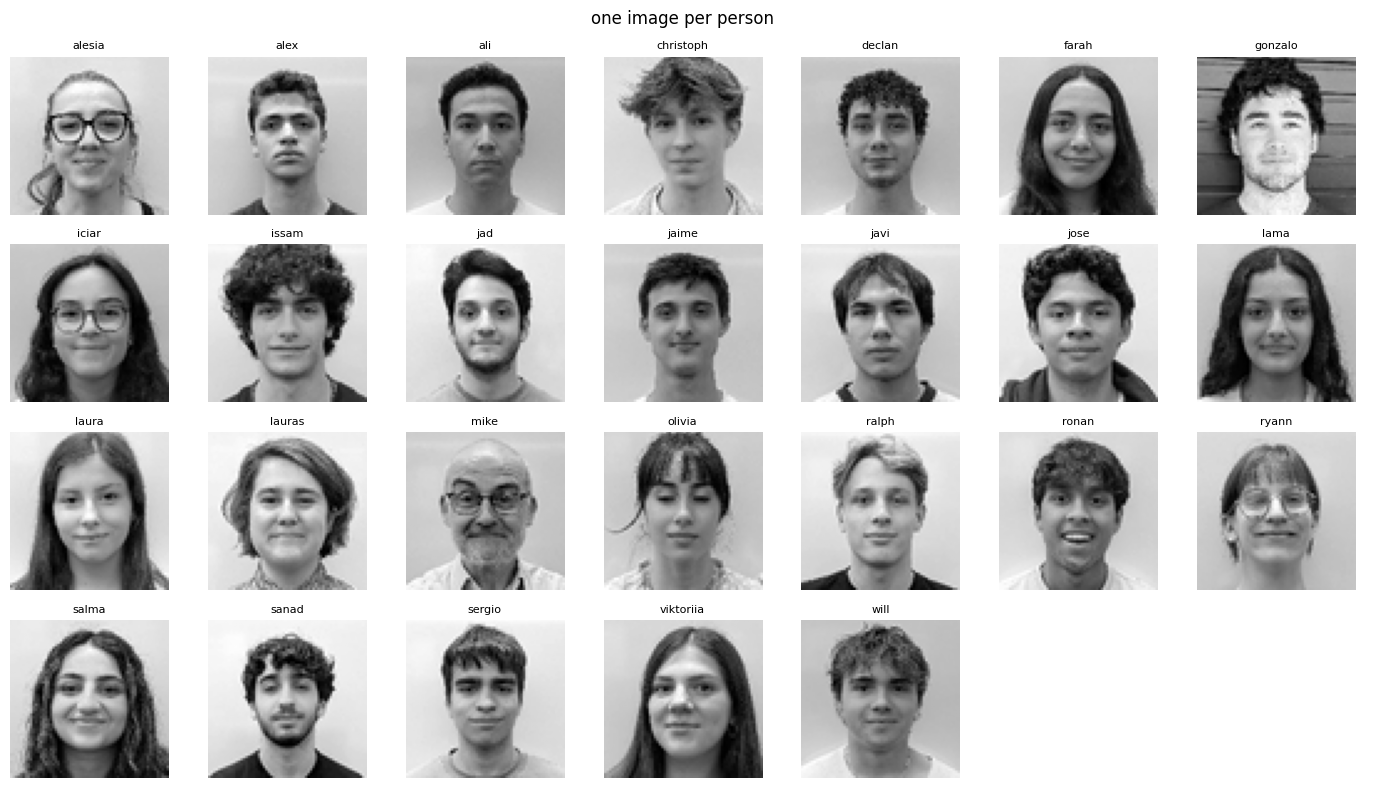

In [35]:
n_people = len(label_map)
fig, axes = plt.subplots(4, 7, figsize=(14, 8))
for i, ax in enumerate(axes.flat):
    if i >= n_people:
        ax.axis("off")
        continue
    person_idx = np.where(y == i)[0][0]
    ax.imshow(X_display[person_idx].reshape(64, 64), cmap="gray")
    ax.set_title(pretty_name(label_map[i]), fontsize=8)
    ax.axis("off")
plt.suptitle("one image per person")
plt.tight_layout()
plt.show()

## 2. leave-one-out split

with only 3 images per person, a random split would give some people 0 test images. instead we take the last image of each person as the test sample, and use the first 2 for training.

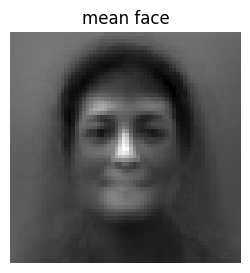

train: (52, 4096)  |  test: (26, 4096)


In [36]:
train_idx, test_idx = [], []

for person_id in np.unique(y):
    idxs = np.where(y == person_id)[0]
    train_idx.extend(idxs[:-1])  # first 2
    test_idx.append(idxs[-1])    # last 1

X_train, y_train = X[train_idx], y[train_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

X_train_display = X_display[train_idx]
X_test_display  = X_display[test_idx]

mean_face = X_train.mean(axis=0)
X_train_c = X_train - mean_face
X_test_c  = X_test  - mean_face

plt.figure(figsize=(3, 3))
plt.imshow(mean_face.reshape(64, 64), cmap="gray")
plt.title("mean face")
plt.axis("off")
plt.show()

print(f"train: {X_train.shape}  |  test: {X_test.shape}")

## 3. pca — eigenfaces

we use:
- a larger $k$ for reconstruction, so the rebuilt faces stay close to the original
- a smaller $k$ for matching, so similarity focuses more on stable facial structure and less on noise, hair, and expression

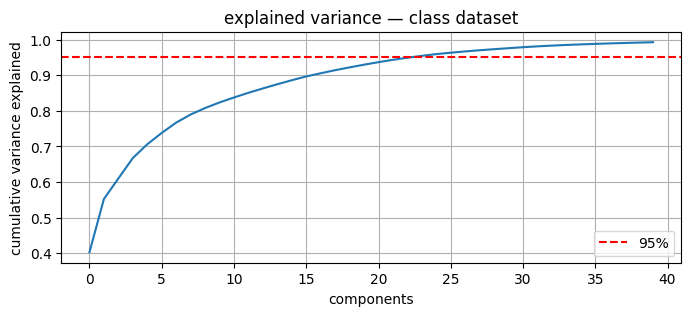

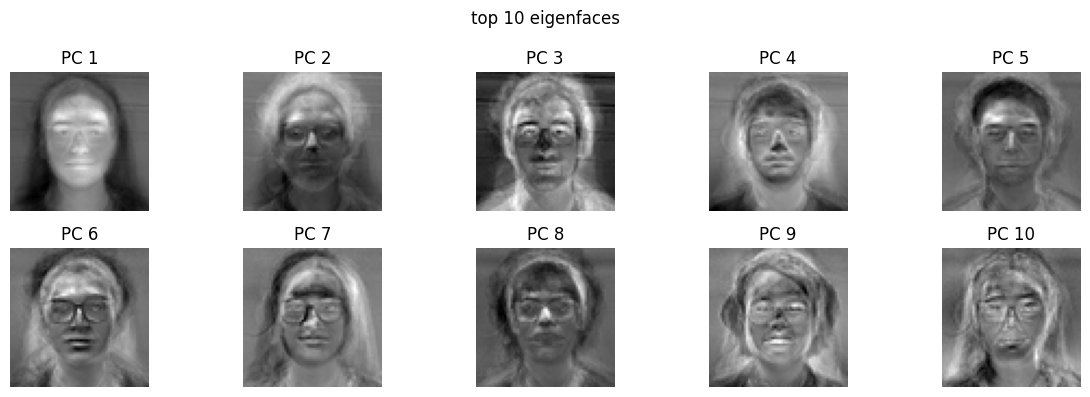

In [37]:
K_REC = 40
K_MATCH = 18
K_MAX = max(K_REC, K_MATCH)

pca = PCA(n_components=K_MAX, svd_solver="randomized", whiten=False)
pca.fit(X_train_c)
eigenfaces = pca.components_

plt.figure(figsize=(8, 3))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.axhline(0.95, color="red", linestyle="--", label="95%")
plt.xlabel("components")
plt.ylabel("cumulative variance explained")
plt.title("explained variance — class dataset")
plt.legend()
plt.grid(True)
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(12, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(eigenfaces[i].reshape(64, 64), cmap="gray")
    ax.set_title(f"PC {i+1}")
    ax.axis("off")
plt.suptitle("top 10 eigenfaces")
plt.tight_layout()
plt.show()

## 4. face reconstruction

reconstruct every test face using the PCA basis.

for each row:
- left = original image
- right = reconstruction

we also show a cosine similarity score between the original test vector and its reconstruction.

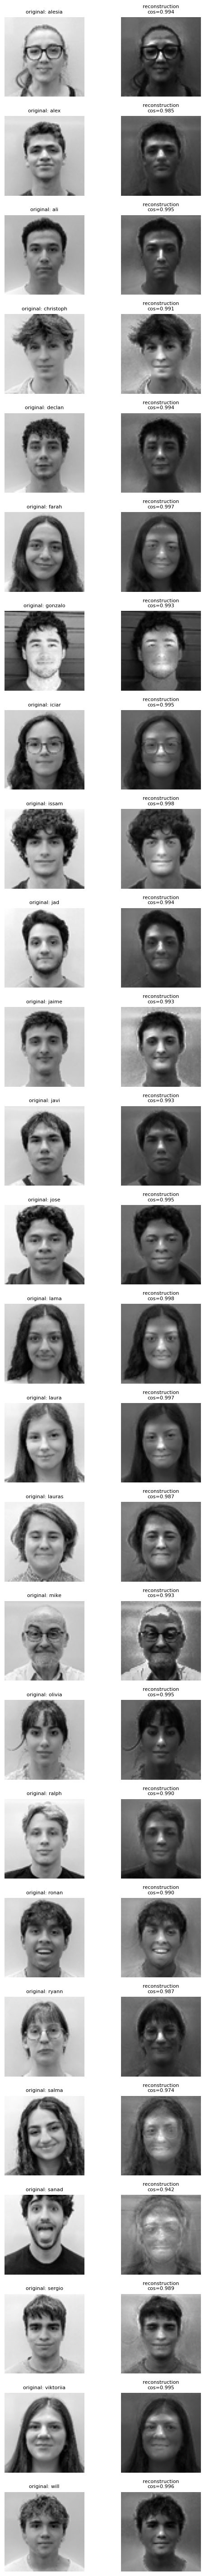

average reconstruction cosine similarity: 0.990


In [38]:
def reconstruct(X_c, components, mean):
    weights = X_c @ components.T
    return weights @ components + mean

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8)

fig, axes = plt.subplots(len(y_test), 2, figsize=(6, len(y_test) * 2.2))

if len(y_test) == 1:
    axes = np.array([axes])

sims = []

for row, i in enumerate(range(len(X_test_c))):
    rec = reconstruct(X_test_c[[i]], eigenfaces[:K_REC], mean_face).reshape(64, 64)
    sim = cosine_similarity(X_test[i], rec.flatten())
    sims.append(sim)

    axes[row, 0].imshow(X_test_display[i].reshape(64, 64), cmap="gray")
    axes[row, 0].set_title(f"original: {pretty_name(label_map[y_test[i]])}", fontsize=8)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(rec, cmap="gray")
    axes[row, 1].set_title(f"reconstruction\ncos={sim:.3f}", fontsize=8)
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

print(f"average reconstruction cosine similarity: {np.mean(sims):.3f}")

## 5. classmate similarity

first, we check the original self-identification task again as a baseline.

then, for the actual similarity task, we compare each test face to the **other classmates only**.

baseline self-match accuracy: 92.31%  (24/26 correct)


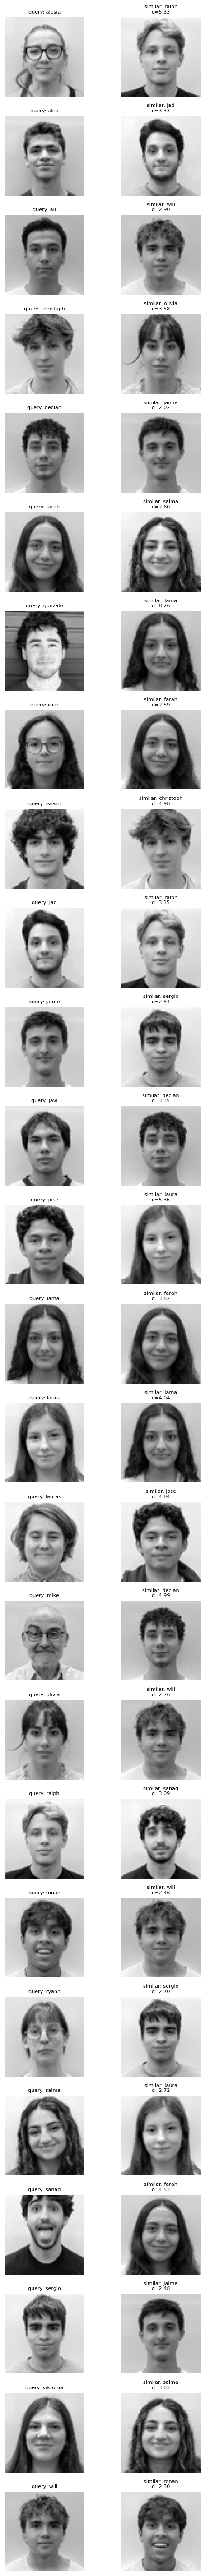

In [39]:
train_weights = X_train_c @ eigenfaces[:K_MATCH].T
test_weights  = X_test_c  @ eigenfaces[:K_MATCH].T

class_ids = np.unique(y_train)

class_centroids = {}
for lbl in class_ids:
    class_centroids[lbl] = train_weights[y_train == lbl].mean(axis=0)

def nearest_class_with_self(query_w):
    best_lbl = None
    best_dist = np.inf
    for lbl in class_ids:
        dist = np.linalg.norm(class_centroids[lbl] - query_w)
        if dist < best_dist:
            best_dist = dist
            best_lbl = lbl
    return best_lbl, best_dist

baseline_preds = []
for i in range(len(test_weights)):
    pred_lbl, _ = nearest_class_with_self(test_weights[i])
    baseline_preds.append(pred_lbl)

baseline_acc = np.mean(np.array(baseline_preds) == y_test)
print(f"baseline self-match accuracy: {baseline_acc:.2%}  ({int(baseline_acc * len(y_test))}/{len(y_test)} correct)")

def best_train_image_for_class(query_w, class_id):
    idxs = np.where(y_train == class_id)[0]
    dists = np.linalg.norm(train_weights[idxs] - query_w, axis=1)
    return idxs[np.argmin(dists)]

def nearest_other_classmate(query_w, true_lbl):
    best_lbl = None
    best_dist = np.inf
    best_idx = None

    for lbl in class_ids:
        if lbl == true_lbl:
            continue
        dist = np.linalg.norm(class_centroids[lbl] - query_w)
        if dist < best_dist:
            best_dist = dist
            best_lbl = lbl
            best_idx = best_train_image_for_class(query_w, lbl)

    return best_lbl, best_dist, best_idx

fig, axes = plt.subplots(len(y_test), 2, figsize=(6, len(y_test) * 2.2))

if len(y_test) == 1:
    axes = np.array([axes])

for row, i in enumerate(range(len(test_weights))):
    query_w = test_weights[i]
    true_lbl = y_test[i]
    pred_lbl, dist, match_idx = nearest_other_classmate(query_w, true_lbl)

    axes[row, 0].imshow(X_test_display[i].reshape(64, 64), cmap="gray")
    axes[row, 0].set_title(f"query: {pretty_name(label_map[true_lbl])}", fontsize=8)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(X_train_display[match_idx].reshape(64, 64), cmap="gray")
    axes[row, 1].set_title(f"similar: {pretty_name(label_map[pred_lbl])}\nd={dist:.2f}", fontsize=8)
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

## 6. celebrity comparison

compare each classmate test image to the celebrity dataset.

for celebrities, we also use **all available images** for each celebrity by averaging them into one celebrity representation in eigenspace. then we only compare within the **same gender**, and show the nearest 2 celebrity matches in a 2-column layout.

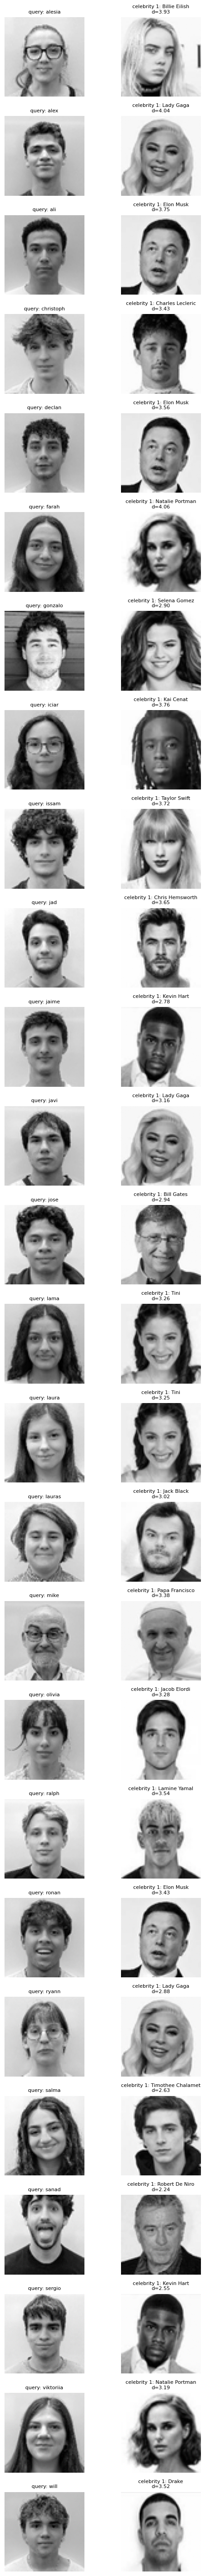

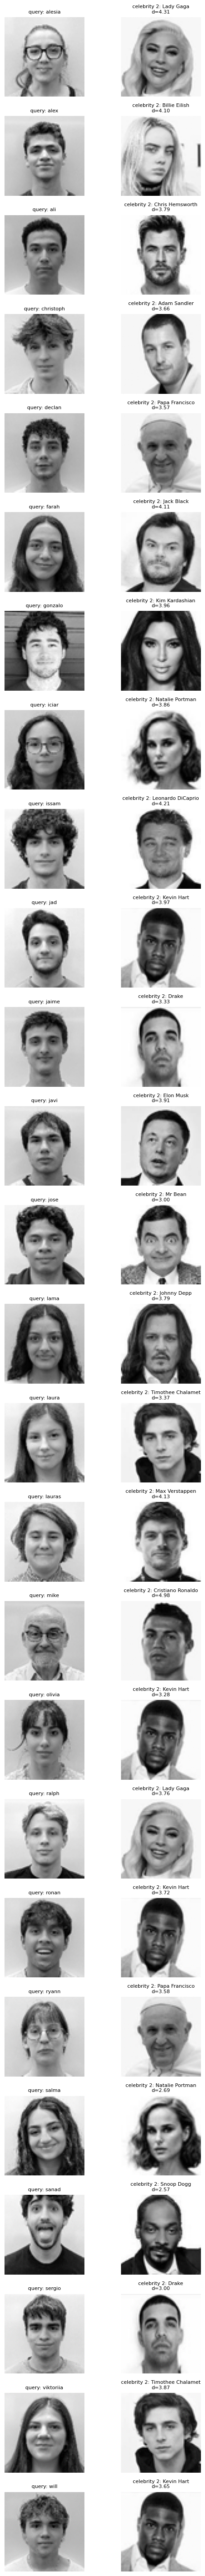

In [40]:
X_celeb, X_celeb_display, y_celeb, celeb_label_map = load_celeb_dataset(CELEB_DATASET_PATH)

if len(X_celeb) == 0:
    print("no celebrity images found in celebrity_pictures")
else:
    X_celeb_c = X_celeb - mean_face
    celeb_weights = X_celeb_c @ eigenfaces[:K_MATCH].T

    celeb_ids = np.unique(y_celeb)

    celeb_centroids = {}
    for lbl in celeb_ids:
        celeb_centroids[lbl] = celeb_weights[y_celeb == lbl].mean(axis=0)

    def best_celeb_image_for_class(query_w, celeb_id):
        idxs = np.where(y_celeb == celeb_id)[0]
        dists = np.linalg.norm(celeb_weights[idxs] - query_w, axis=1)
        return idxs[np.argmin(dists)]

    def nearest_two_celebrities(query_w):
        matches = []
        for lbl in celeb_ids:
            dist = np.linalg.norm(celeb_centroids[lbl] - query_w)
            best_idx = best_celeb_image_for_class(query_w, lbl)
            matches.append((lbl, dist, best_idx))

        matches.sort(key=lambda x: x[1])
        return matches[:2]

    # nearest celebrity
    fig, axes = plt.subplots(len(y_test), 2, figsize=(6, len(y_test) * 2.2))

    if len(y_test) == 1:
        axes = np.array([axes])

    for row, i in enumerate(range(len(test_weights))):
        query_w = test_weights[i]
        matches = nearest_two_celebrities(query_w)
        celeb_lbl, dist, celeb_idx = matches[0]

        axes[row, 0].imshow(X_test_display[i].reshape(64, 64), cmap="gray")
        axes[row, 0].set_title(f"query: {pretty_name(label_map[y_test[i]])}", fontsize=8)
        axes[row, 0].axis("off")

        axes[row, 1].imshow(X_celeb_display[celeb_idx].reshape(64, 64), cmap="gray")
        axes[row, 1].set_title(f"celebrity 1: {pretty_name(celeb_label_map[celeb_lbl])}\nd={dist:.2f}", fontsize=8)
        axes[row, 1].axis("off")

    plt.tight_layout()
    plt.show()

    # second nearest celebrity
    fig, axes = plt.subplots(len(y_test), 2, figsize=(6, len(y_test) * 2.2))

    if len(y_test) == 1:
        axes = np.array([axes])

    for row, i in enumerate(range(len(test_weights))):
        query_w = test_weights[i]
        matches = nearest_two_celebrities(query_w)
        celeb_lbl, dist, celeb_idx = matches[1]

        axes[row, 0].imshow(X_test_display[i].reshape(64, 64), cmap="gray")
        axes[row, 0].set_title(f"query: {pretty_name(label_map[y_test[i]])}", fontsize=8)
        axes[row, 0].axis("off")

        axes[row, 1].imshow(X_celeb_display[celeb_idx].reshape(64, 64), cmap="gray")
        axes[row, 1].set_title(f"celebrity 2: {pretty_name(celeb_label_map[celeb_lbl])}\nd={dist:.2f}", fontsize=8)
        axes[row, 1].axis("off")

    plt.tight_layout()
    plt.show()